In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_parquet("../data/processed/decoded_pool_transactions.parquet")

## Split into each individual transaction type

In [3]:
d = df
swaps = (
    d[d["event"] == "Swap"]
    .copy()
    [[
        "block_timestamp", "block_number", "tx_hash", "log_index", "tx_index",
        "sender", "recipient",
        "amount0", "amount1",
        "sqrtPriceX96", "liquidity", "tick"
    ]]
)
mints = (
    d[d["event"] == "Mint"]
    .copy()
    [[
        "block_timestamp", "block_number", "tx_hash", "log_index", "tx_index",
        "sender", "owner",
        "tickLower", "tickUpper",
        "amount", "amount0", "amount1"
    ]]
)

burns = (
    d[d["event"] == "Burn"]
    .copy()
    [[
        "block_timestamp", "block_number", "tx_hash", "log_index", "tx_index",
        "owner",
        "tickLower", "tickUpper",
        "amount", "amount0", "amount1"
    ]]
)

collects = (
    d[d["event"] == "Collect"]
    .copy()
    [[
        "block_timestamp", "block_number", "tx_hash", "log_index", "tx_index",
        "recipient", "owner",
        "tickLower", "tickUpper",
        "amount0", "amount1"
    ]]
)


In [4]:
swaps.head()

,block_timestamp,block_number,tx_hash,log_index,tx_index,sender,recipient,amount0,amount1,sqrtPriceX96,liquidity,tick
0,2022-11-16 21:34:59,15985296,313f88a08cbda72eca653433f60d35ac6044597fe03cae...,327,150,0xE592427A0AEce92De3Edee1F18E0157C05861564,0xE592427A0AEce92De3Edee1F18E0157C05861564,-49540580434,41079000000000000000,2278156445805771936898597302158205,11457725834822228820,205341.0
10,2022-11-16 21:43:23,15985338,1cf0bdee0932b166e7bc5c0b63a8ff79f9e0c14a9a5627...,178,125,0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45,0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45,-269462519,223465983574542948,2278157986398071449751664235831037,11457726272451347795,205341.0
11,2022-11-16 21:44:11,15985342,0dab5f347d405ccb58406816534274f09f3a92714bee0c...,12,2,0x0087BB802D9C0e343F00510000729031ce00bf27,0x0087BB802D9C0e343F00510000729031ce00bf27,-119856592724,99427365180799991808,2278843446577326412808790402614249,11457726272451347795,205347.0
14,2022-11-16 21:45:23,15985348,7b149365d91334462a8f45432060c8009b58d189c2c3d9...,252,165,0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45,0x083cD3AAa1e6DE02be95Cc9D9eC7e314BBf51d69,-421786746,350000000000000000,2278845859505219080785325513320862,11457726272451347795,205347.0
15,2022-11-16 21:45:35,15985349,971118fea7a5cb02e7304a7094043282deab2c526dcaa2...,238,118,0x68b3465833fb72A70ecDF485E0e4C7bD8665Fc45,0x055FD23A4d5d454D005a28Dca00f3F0b487D8DFB,-476537505,395433247900114811,2278848585653543499292716632901860,11457726272451347795,205347.0


## Save each

In [5]:
swaps.to_parquet("../data/processed/usdcweth_swaps.parquet", index=False)
mints.to_parquet("../data/processed/usdcweth_mints.parquet", index=False)
burns.to_parquet("../data/processed/usdcweth_burns.parquet", index=False)
collects.to_parquet("../data/processed/usdcweth_collects.parquet", index=False)

In [7]:
USDC_DEC = 6
WETH_DEC = 18
Q192 = 2 ** 192

sw = swaps.sort_values("block_timestamp").copy()
sqrtP = swaps["sqrtPriceX96"].astype(float)
sw["price_usdc_per_weth"] = (sqrtP**2 / Q192)*(10 ** (USDC_DEC - WETH_DEC))

Text(0.5, 1.0, 'USDC/WETH Mid Price from Pool Over Time')

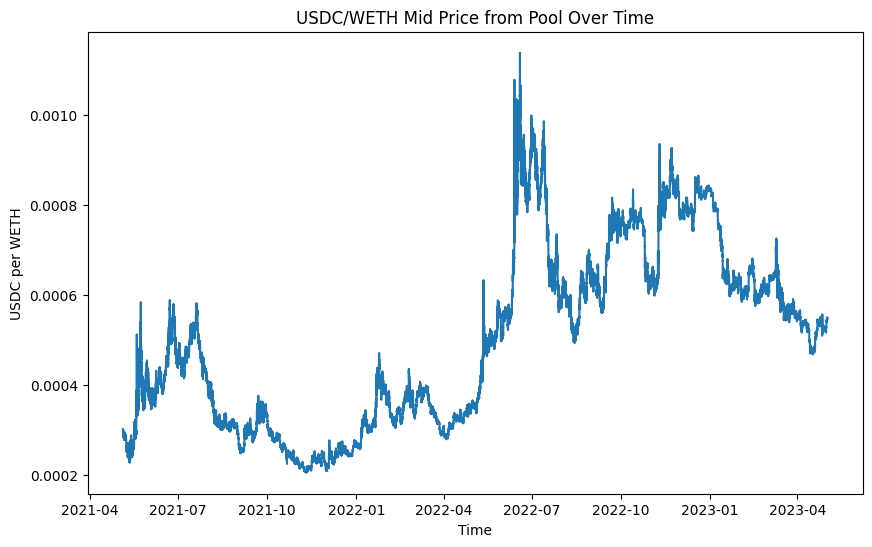

In [9]:
fig, ax = plt.subplots(figsize=(10,6))
ax.plot(sw["block_timestamp"], sw["price_usdc_per_weth"].astype(float))
ax.set_xlabel("Time")
ax.set_ylabel("USDC per WETH")
ax.set_title("USDC/WETH Mid Price from Pool Over Time")

In [10]:
fig.savefig("../figures/USDC-WETH_Mid_Price_from_Pool_Over_Time.png", dpi=300, bbox_inches="tight")